In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [2]:
conn = sqlite3.connect('inventory.db')

df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,description,ActualPrice,PurchasePrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,26.27,1750.0,145080,3811251.60,5.101920e+06,672819.31,142049.0,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,23.19,1750.0,164038,3804041.22,4.819073e+06,561512.37,160247.0,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,18.24,1750.0,187407,3418303.68,4.538121e+06,461140.15,187140.0,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,16.17,1750.0,201682,3261197.94,4.475973e+06,420050.01,200412.0,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,21.89,1750.0,138109,3023206.01,4.223108e+06,545778.28,135838.0,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


## Exploratory Data Analysis

In [3]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
ActualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05


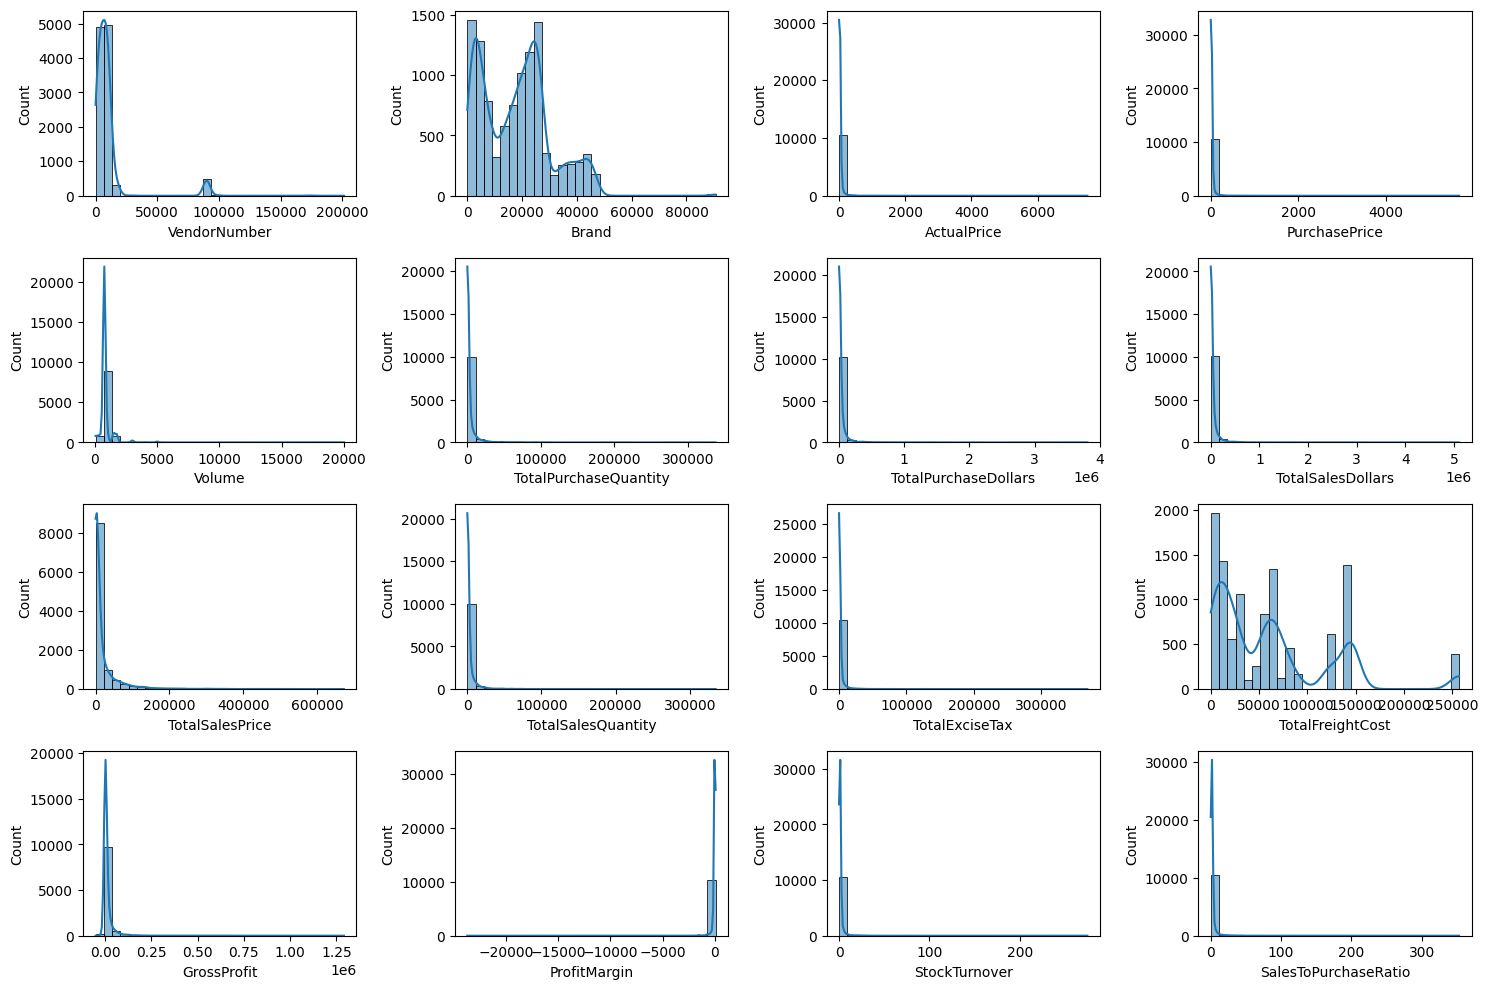

In [4]:
#Distribution plots for numerical cols
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1)
    sns.histplot(df[col], kde=True, bins=30)
plt.tight_layout()
plt.show()

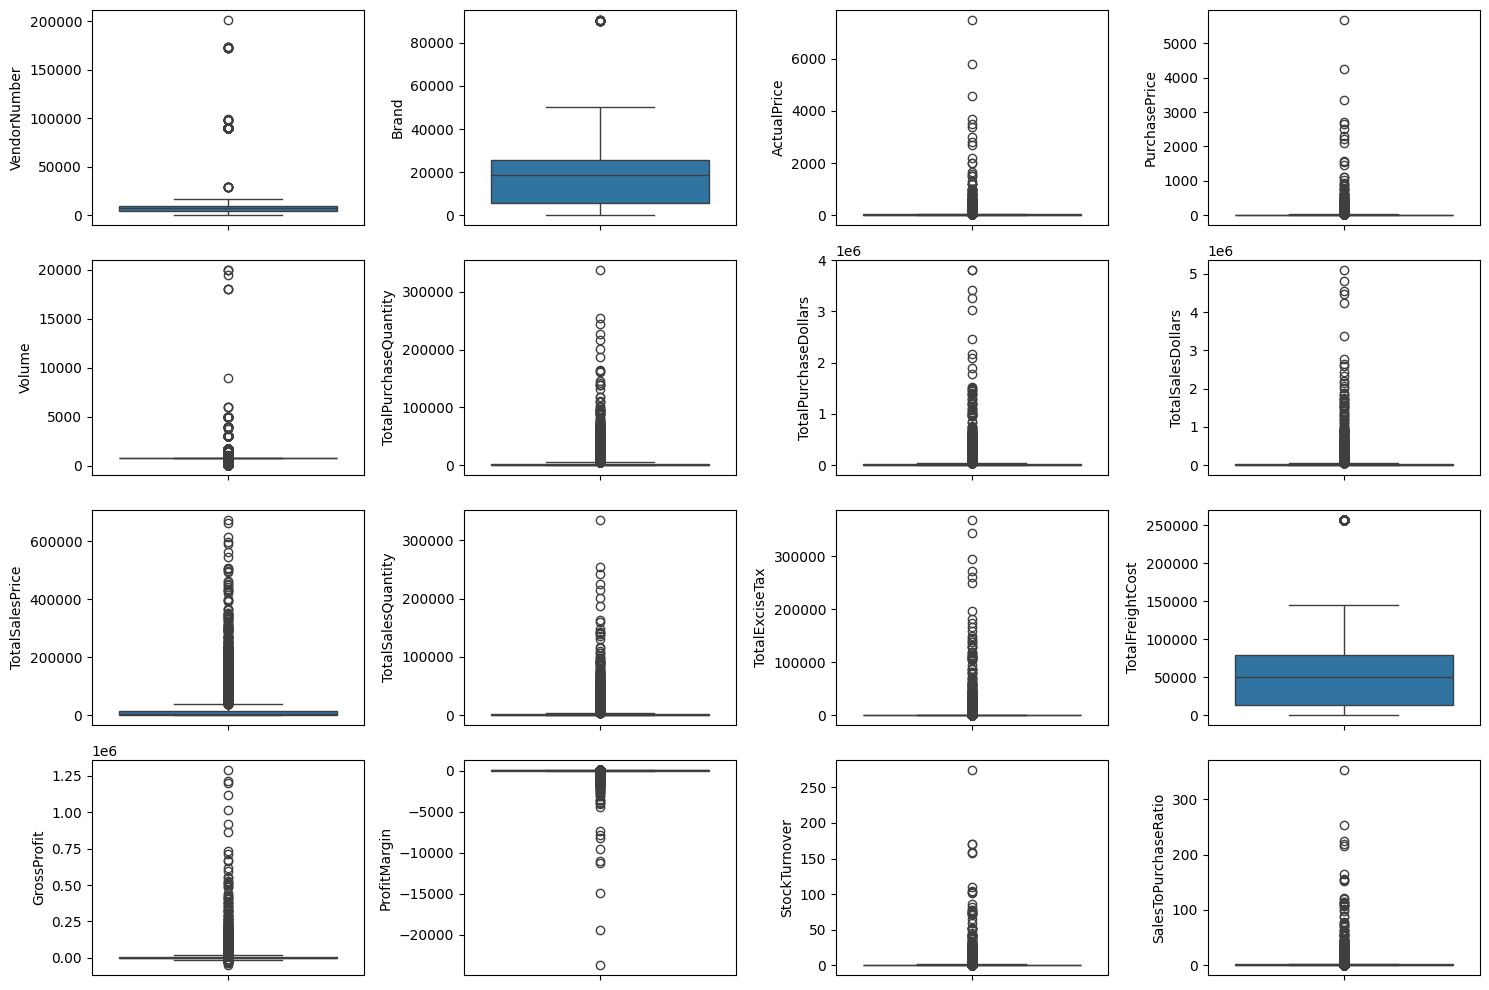

In [5]:
#Outlier Detection with Boxplots
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1)
    sns.boxplot(y=df[col])
plt.tight_layout()
plt.show()

In [6]:
#removing inconsistencies
df = pd.read_sql_query("""
SELECT * FROM vendor_sales_summary
WHERE GrossProfit > 0 
AND ProfitMargin > 0
AND TotalSalesQuantity > 0
""",conn)

In [7]:
df

,VendorNumber,VendorName,Brand,description,ActualPrice,PurchasePrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,TotalFreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,26.27,1750.0,145080,3811251.60,5.101920e+06,672819.31,142049.0,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,23.19,1750.0,164038,3804041.22,4.819073e+06,561512.37,160247.0,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,18.24,1750.0,187407,3418303.68,4.538121e+06,461140.15,187140.0,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,16.17,1750.0,201682,3261197.94,4.475973e+06,420050.01,200412.0,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,21.89,1750.0,138109,3023206.01,4.223108e+06,545778.28,135838.0,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8560,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,4.99,1.32,750.0,2,2.64,1.595000e+01,10.96,5.0,0.55,27100.41,13.31,83.448276,2.500000,6.041667
8561,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.49,0.39,50.0,6,2.34,6.566000e+01,1.47,134.0,7.04,50293.62,63.32,96.436186,22.333333,28.059829
8562,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.99,0.74,50.0,2,1.48,1.980000e+00,0.99,2.0,0.10,14069.87,0.50,25.252525,1.000000,1.337838
8563,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.99,1.47,200.0,1,1.47,1.432800e+02,77.61,72.0,15.12,257032.07,141.81,98.974037,72.000000,97.469388


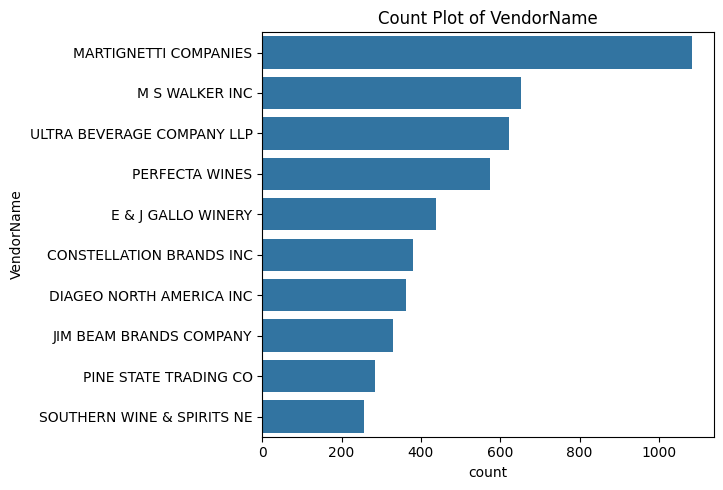

In [8]:
#Count Plots for Categorical columns
categorical_cols = ["VendorName"]

plt.figure(figsize=(12,5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col], order = df[col].value_counts().index[:10])
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

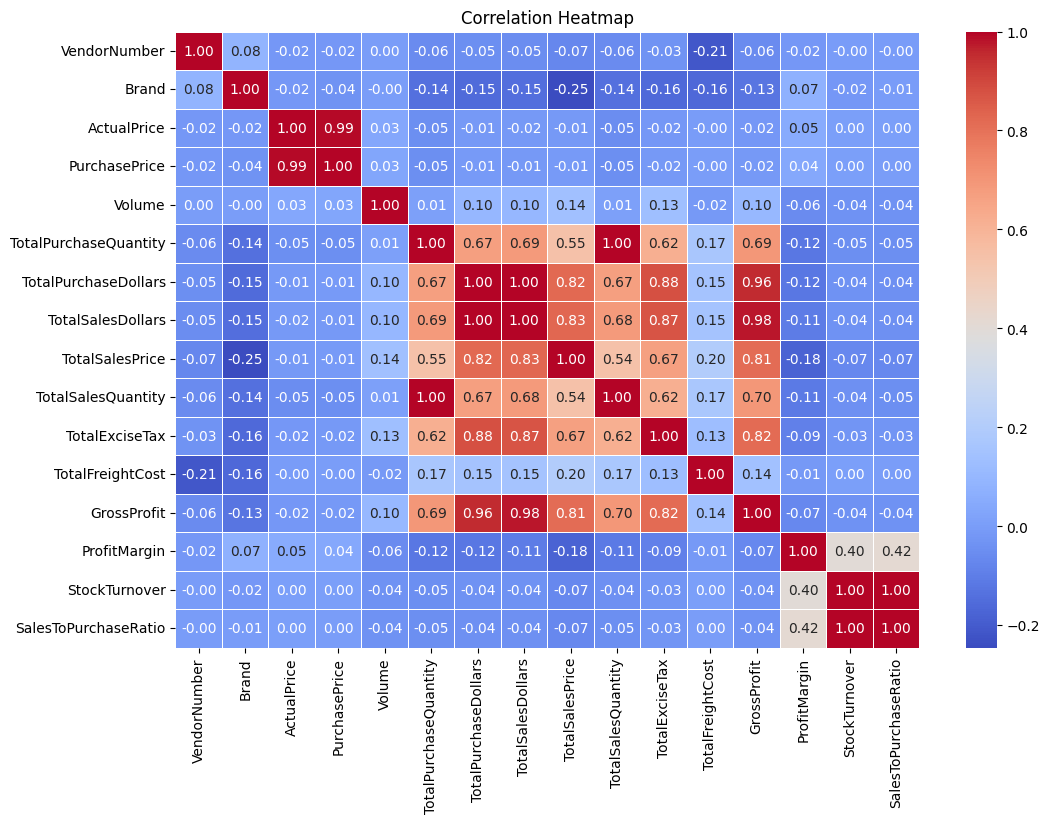

In [9]:
#Correlation Heatmap
plt.figure(figsize=(12,8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

## Data Analysis

In [10]:
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      6.799010e+07
MARTIGNETTI COMPANIES         3.933036e+07
PERNOD RICARD USA             3.206320e+07
JIM BEAM BRANDS COMPANY       3.142302e+07
BACARDI USA INC               2.485482e+07
CONSTELLATION BRANDS INC      2.421875e+07
E & J GALLO WINERY            1.839990e+07
BROWN-FORMAN CORP             1.824723e+07
ULTRA BEVERAGE COMPANY LLP    1.650254e+07
M S WALKER INC                1.470646e+07
Name: TotalSalesDollars, dtype: float64

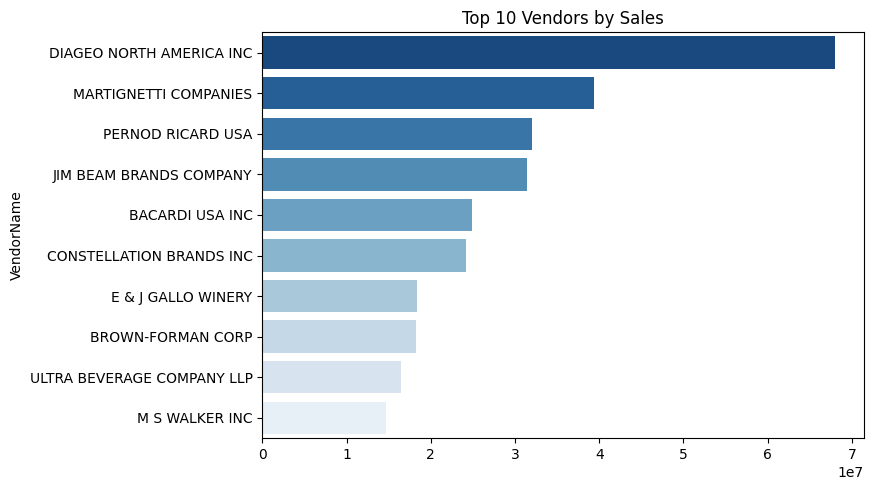

In [11]:
plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")
plt.tight_layout()
plt.show()

#### Which vendors contribute the most to total purchase dollars?

In [12]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000: .2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:.2f}K"
    else:
        return str(value)

In [13]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum', 
    'TotalSalesDollars':'sum'
}).reset_index()

In [14]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [15]:
round(vendor_performance.sort_values('PurchaseContribution%', ascending=False),2)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.30
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.30
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.76
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.64
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.67
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
107,UNCORKED,118.74,58.20,176.94,0.00
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [16]:
top_vendors= vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ADAMBA IMPORTS INTL INC,446.16,258.3700000000003,704.5300000000003,0.000145
1,ALISA CARR BEVERAGES,25.70K,78.77K,104.47K,0.008361
2,ALTAMAR BRANDS LLC,11.71K,4.00K,15.71K,0.003809
3,AMERICAN SPIRITS EXCHANGE,934.08,577.0800000000003,1.51K,0.000304
4,AMERICAN VINTAGE BEVERAGE,104.44K,35.17K,139.60K,0.033981
5,ATLANTIC IMPORTING COMPANY,41.12K,18.16K,59.27K,0.013378
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.671926
7,BANFI PRODUCTS CORP,1.61M,1.02M,2.63M,0.523248
8,BLACK PRINCE DISTILLERY INC,5.85K,5.75K,11.60K,0.001905
9,BLACK ROCK SPIRITS LLC,1.15K,897.0800000000006,2.05K,0.000375


In [17]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
0,ADAMBA IMPORTS INTL INC,446.16,258.3700000000003,704.5300000000003,0.000145,0.000145
1,ALISA CARR BEVERAGES,25.70K,78.77K,104.47K,0.008361,0.008507
2,ALTAMAR BRANDS LLC,11.71K,4.00K,15.71K,0.003809,0.012316
3,AMERICAN SPIRITS EXCHANGE,934.08,577.0800000000003,1.51K,0.000304,0.012619
4,AMERICAN VINTAGE BEVERAGE,104.44K,35.17K,139.60K,0.033981,0.046600
5,ATLANTIC IMPORTING COMPANY,41.12K,18.16K,59.27K,0.013378,0.059978
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.671926,5.731904
7,BANFI PRODUCTS CORP,1.61M,1.02M,2.63M,0.523248,6.255152
8,BLACK PRINCE DISTILLERY INC,5.85K,5.75K,11.60K,0.001905,6.257057
9,BLACK ROCK SPIRITS LLC,1.15K,897.0800000000006,2.05K,0.000375,6.257432


#### How much of total procurement is dependent on the top vendors?

In [18]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Total Purchase Contribution of top 10 vendors is 6.26%


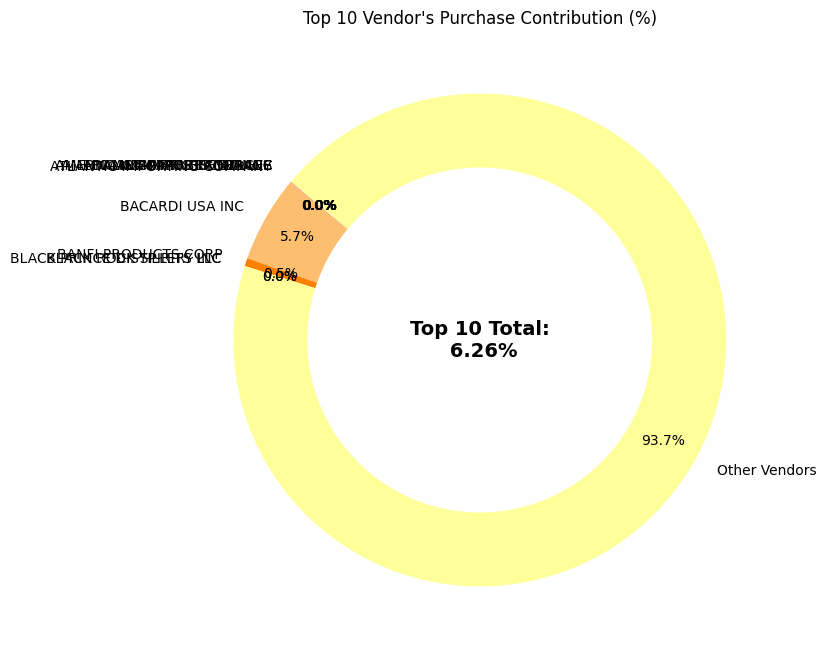

In [19]:
vendors = list(top_vendors ['VendorName'].values)
purchase_contributions = list(top_vendors ['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors. append ("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

#Add Total Contribution annotation in the center
plt.text(0,0,f"Top 10 Total:\n{total_contribution: .2f}%", fontsize = 14, fontweight='bold', ha = 'center', va = 'center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

In [20]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [21]:
df['OrderSize'] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small","Medium","Large"])

In [22]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


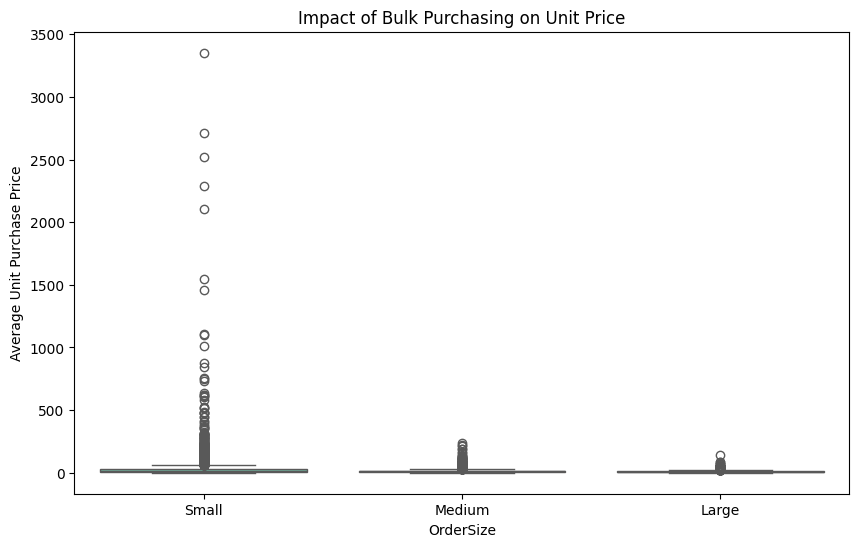

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("OrderSize")
plt.ylabel("Average Unit Purchase Price")
plt.show()

#### Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [24]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean()

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
ALTAMAR BRANDS LLC,0.959375
AMERICAN SPIRITS EXCHANGE,0.875000
AMERICAN VINTAGE BEVERAGE,0.962801
ATLANTIC IMPORTING COMPANY,0.893078
...,...
WEIN BAUER INC,0.847015
WESTERN SPIRITS BEVERAGE CO,0.896930
WILLIAM GRANT & SONS INC,0.908237


#### How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [25]:
df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital:  2.71M


In [26]:
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

#Sort Vendors with the Highest Locked Capital 
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue",ascending = False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


#### What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

In [27]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

In [28]:
top_threshold = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_threshold = df[df["TotalSalesDollars"] >= low_threshold]["ProfitMargin"].dropna()

In [29]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [30]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

# --- Print Statements (Fixed Braces) ---
print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(12, 6))

# --- Top Vendors Plot (Blue) ---
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", linewidth=2, label=f"Top Mean: {top_mean:.2f}")

# --- Low Vendors Plot (Orange for contrast) ---
sns.histplot(low_vendors, kde=True, color="orange", bins=30, alpha=0.5, label="Low Vendors") # Fixed Label
plt.axvline(low_lower, color="orange", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="orange", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="orange", linestyle="-", linewidth=2, label=f"Low Mean: {low_mean:.2f}")

# --- Finalize Plot ---
plt.title("Confidence Interval Comparison: Top vs Low Vendors")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")

# Move legend outside if it covers the data
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.grid(axis='y', alpha=0.3)
plt.tight_layout() # Prevents label cutoff
plt.show()

TypeError: can only concatenate str (not "float") to str

In [31]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] >= low_threshold]["ProfitMargin"].dropna()

#Perform Two-Sample T-Test
t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var = False)

#Print Results
print(f"T-Statistic: {t_stat:.4f}, P-value:{p_value:.4f}")
if p_value < 0.05:
    print("Reject H0 = There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H0: No significant difference in profit margins.")

T-Statistic: -19.8387, P-value:0.0000
Reject H0 = There is a significant difference in profit margins between top and low-performing vendors.


In [3]:
conn = sqlite3.connect('inventory.db')

In [4]:
query = "SELECT * FROM vendor_sales_summary"
df = pd.read_sql_query(query, conn)
df.to_csv('vendor_sales_summary.csv', index=False)
conn.close()
print("CSV file created successfully!")


CSV file created successfully!
